In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("sales_data.csv")

print("FIRST 5 RECORDS")
print(df.head())

FIRST 5 RECORDS
   Order_ID        Date Region Product     Category  Quantity  Price  Cost
0      1001  01-01-2026  South  Laptop  Electronics         5    750   748
1      1002  02-01-2026  North   Phone  Electronics        10    500   498
2      1003  03-01-2026   East  Tablet  Electronics         7    320   318
3      1004  04-01-2026   West   Chair    Furniture        12     85    83
4      1005  05-01-2026  South    Desk    Furniture         4    150   148


In [ ]:
# import pandas as pd

# # Load dataset
# df = pd.read_csv("sales_data.csv")

# Remove completely empty rows
df.dropna(how='all', inplace=True)

# Convert Date column correctly (DD-MM-YYYY)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Remove invalid dates
df = df.dropna(subset=['Date'])

# Reset index
df.reset_index(drop=True, inplace=True)

# Check dataset
print(df.head())

print("\nDATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

   Order_ID       Date Region Product     Category  Quantity  Price  Cost
0      1001 2026-01-01  South  Laptop  Electronics         5    750   748
1      1002 2026-01-02  North   Phone  Electronics        10    500   498
2      1003 2026-01-03   East  Tablet  Electronics         7    320   318
3      1004 2026-01-04   West   Chair    Furniture        12     85    83
4      1005 2026-01-05  South    Desk    Furniture         4    150   148

DATA TYPES
Order_ID             int64
Date        datetime64[ns]
Region              object
Product             object
Category            object
Quantity             int64
Price                int64
Cost                 int64
dtype: object

MISSING VALUES
Order_ID    0
Date        0
Region      0
Product     0
Category    0
Quantity    0
Price       0
Cost        0
dtype: int64


In [46]:
# ==========================================
# CREATE NEW COLUMNS
# ==========================================

# Total Sales
df['Sales'] = df['Quantity'] * df['Price']



# Profit column
df['Profit'] = df['Sales'] - df['Cost'] 

print("\nUPDATED DATA")
print(df.tail())


UPDATED DATA
    Order_ID       Date Region   Product     Category  Quantity  Price  Cost  \
94      1095 2026-04-05   East  Keyboard  Electronics        15     35    33   
95      1096 2026-04-06   West     Chair    Furniture        12     85    83   
96      1097 2026-04-07  South      Desk    Furniture         4    150   148   
97      1098 2026-04-08  North       Pen   Stationery        50      2     1   
98      1099 2026-04-09   East   Monitor  Electronics         6    220   218   

    Sales  Profit  Month  
94    525     492  April  
95   1020     937  April  
96    600     452  April  
97    100      99  April  
98   1320    1102  April  


In [47]:
# ==========================================
# TOTAL SALES
# ==========================================

total_sales = np.sum(df['Sales'])

print("\nTOTAL SALES:", total_sales)

# ==========================================
# REGION WISE SALES
# ==========================================

region_sales = df.groupby('Region')['Sales'].sum()

print("\nREGION WISE SALES")
print(region_sales)


TOTAL SALES: 83145

REGION WISE SALES
Region
East     18905
North    20473
South    21544
West     22223
Name: Sales, dtype: int64


In [37]:
# ==========================================
# PRODUCT WISE SALES
# ==========================================

product_sales = df.groupby('Product')['Sales'].sum()

print("\nPRODUCT WISE SALES")
print(product_sales)


PRODUCT WISE SALES
Product
AC                900
Action Camera     900
Backpack         1064
Bag               990
Bed               850
                 ... 
VR Headset        750
Wallet            374
Watch            2520
Wire              360
Wrench            180
Name: Sales, Length: 75, dtype: int64


In [51]:
# ==========================================
# MONTHLY SALES
# ==========================================

df['Month'] = df['Date'].dt.month_name()

# Correct month order
month_order = [
    'January', 'February', 'March', 'April'
]

# Convert to categorical
df['Month'] = pd.Categorical(
    df['Month'],
    categories=month_order,
    ordered=True
)

monthly_sales = df.groupby('Month')['Sales'].sum()

print("\nMONTHLY SALES")
print(monthly_sales)


MONTHLY SALES
Month
January     33109
February    19878
March       24423
April        5735
Name: Sales, dtype: int64


C:\Users\Ibrahim\AppData\Local\Temp\ipykernel_27788\3367843160.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby('Month')['Sales'].sum()


In [52]:
# ==========================================
# TOP SELLING PRODUCT
# ==========================================

top_product = product_sales.idxmax()

print("\nTOP SELLING PRODUCT:", top_product)


TOP SELLING PRODUCT: Phone


In [53]:
# ==========================================
# NUMPY ANALYSIS
# ==========================================

sales_array = np.array(df['Sales'])

print("\nNUMPY ANALYSIS")
print("Average Sales:", np.mean(sales_array))
print("Maximum Sales:", np.max(sales_array))
print("Minimum Sales:", np.min(sales_array))



NUMPY ANALYSIS
Average Sales: 839.8484848484849
Maximum Sales: 5000
Minimum Sales: 100


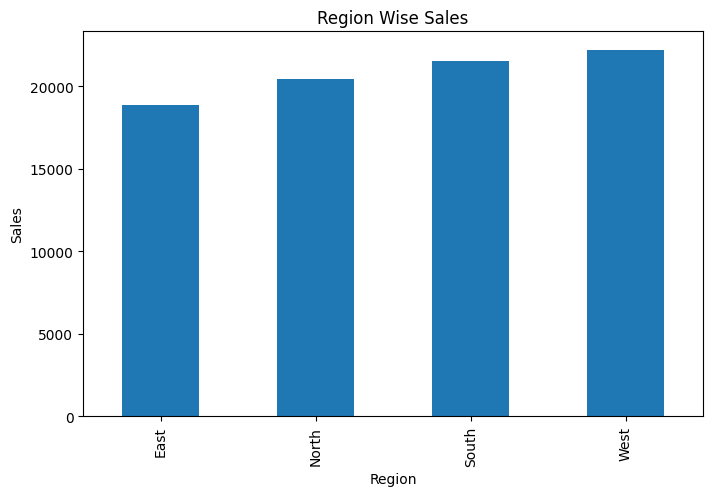

In [54]:
# ==========================================
# VISUALIZATION
# ==========================================

# ----- BAR CHART -----

plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Region Wise Sales")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

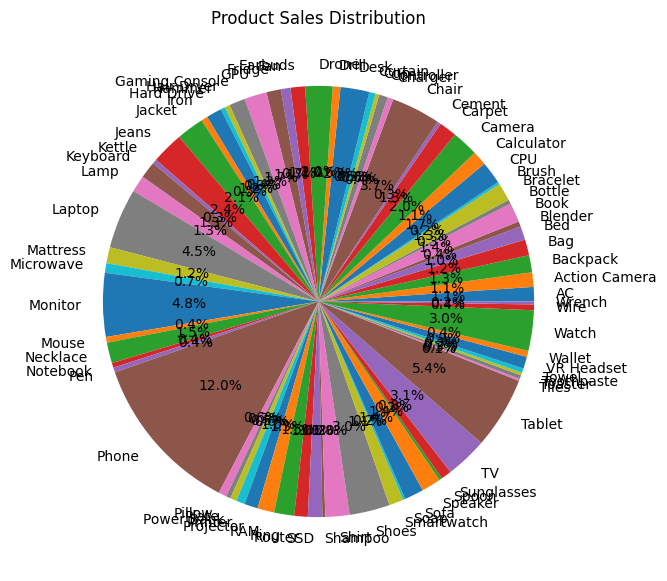

In [55]:

# ----- PIE CHART -----

plt.figure(figsize=(7,7))

product_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Product Sales Distribution")

plt.ylabel("")

plt.show()

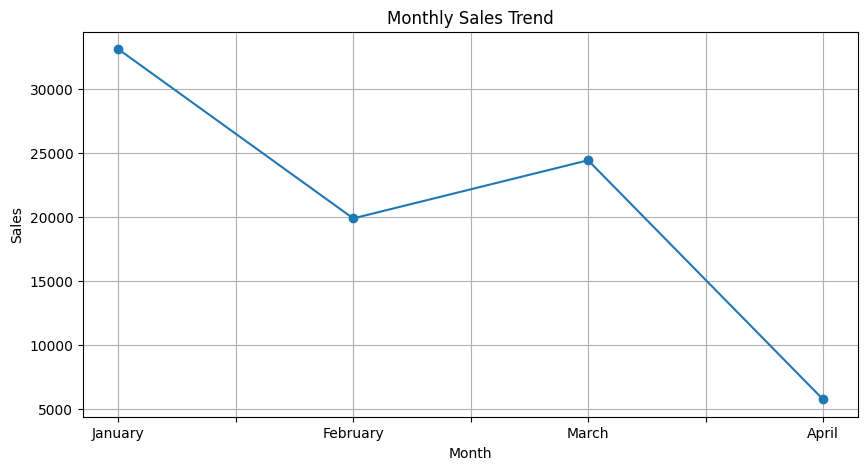

In [56]:
# ----- LINE CHART -----

plt.figure(figsize=(10,5))

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [57]:
# ==========================================
# SAVE REPORT
# ==========================================

df.to_csv("final_sales_report.csv", index=False)

print("\nREPORT SAVED SUCCESSFULLY")


REPORT SAVED SUCCESSFULLY
